In [ ]:
# uncomment this block to skip reprocessing on kernel restart
# X_train_scaled = np.load("data/X_train_scaled.npy")
# X_val_scaled = np.load("data/X_val_scaled.npy")
# X_test_scaled = np.load("data/X_test_scaled.npy")
# y_train = np.load("data/y_train.npy")
# y_val = np.load("data/y_val.npy")
# y_test = np.load("data/y_test.npy")

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/cicids2017_cleaned.csv")
print(df.shape)
print(df["Attack Type"].value_counts())

(2520751, 53)
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [2]:
print(df.dtypes.value_counts())
print(df.isnull().sum().sum())
print(df.head(2))

int64      32
float64    20
str         1
Name: count, dtype: int64
0
   Destination Port  Flow Duration  Total Fwd Packets  \
0                22        1266342                 41   
1                22        1319353                 41   

   Total Length of Fwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  \
0                         2664                    456                      0   
1                         2664                    456                      0   

   Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  \
0                64.97561             109.864573                    976   
1                64.97561             109.864573                    976   

   Bwd Packet Length Min  ...  Init_Win_bytes_backward  act_data_pkt_fwd  \
0                      0  ...                      243                24   
1                      0  ...                      243                24   

   min_seg_size_forward  Active Mean  Active Max  Active Min  

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["Attack Type"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Bots': np.int64(0), 'Brute Force': np.int64(1), 'DDoS': np.int64(2), 'DoS': np.int64(3), 'Normal Traffic': np.int64(4), 'Port Scanning': np.int64(5), 'Web Attacks': np.int64(6)}


In [4]:
X = df.drop(columns=["Attack Type", "label"])
y = df["label"]

print("features shape:", X.shape)
print("Labels:", y.shape)

features shape: (2520751, 52)
Labels: (2520751,)


In [5]:
from sklearn.model_selection import train_test_split

# first split off 20% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# split remaining 80% into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1613280, 52)
Val: (403320, 52)
Test: (504151, 52)


In [6]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# save scaler for backend use later
joblib.dump(scaler, "backend/models/scaler.pkl")
print("done")

done


In [7]:
from sklearn.ensemble import IsolationForest

# get only normal traffic rows for training
X_benign = X_train_scaled[y_train == 4]
print("Benign samples for IF training:", X_benign.shape)

# train isolation forest on benign only
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.169,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_benign)
print("done")

Benign samples for IF training: (1340836, 52)
done


In [8]:
# get anomaly scores on validation set
if_preds = iso_forest.predict(X_val_scaled)

# isolation forest returns 1 for normal, -1 for anomaly
# convert to binary: 0 = normal, 1 = anomaly
if_binary = (if_preds == -1).astype(int)
y_val_binary = (y_val != 4).astype(int)  # 0 = normal, 1 = attack

from sklearn.metrics import classification_report
print(classification_report(y_val_binary, if_binary, target_names=["Normal", "Anomaly"]))

              precision    recall  f1-score   support

      Normal       0.91      0.83      0.87    335209
     Anomaly       0.42      0.60      0.49     68111

    accuracy                           0.79    403320
   macro avg       0.67      0.72      0.68    403320
weighted avg       0.83      0.79      0.81    403320



In [9]:
import joblib

joblib.dump(iso_forest, "backend/models/isolation_forest.pkl")
print("done")

done


In [10]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_baseline.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print("done")

done


In [11]:
from sklearn.metrics import classification_report

y_pred = xgb_baseline.predict(X_val_scaled)

print(classification_report(y_val, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

          Bots       0.86      0.74      0.80       312
   Brute Force       0.99      1.00      0.99      1464
          DDoS       1.00      1.00      1.00     20482
           DoS       0.99      1.00      0.99     30999
Normal Traffic       1.00      1.00      1.00    335209
 Port Scanning       0.99      1.00      0.99     14511
   Web Attacks       0.91      0.97      0.94       343

      accuracy                           1.00    403320
     macro avg       0.96      0.96      0.96    403320
  weighted avg       1.00      1.00      1.00    403320



These metrics reflect performance on the CICIDS2017 validation split 
under random stratified sampling. This is known to be easier than 
real-world traffic due to scenario-specific patterns shared across 
splits. Generalization to arbitrary networks is unknown.

In [12]:
y_train_pred = xgb_baseline.predict(X_train_scaled)
from sklearn.metrics import f1_score

train_f1 = f1_score(y_train, y_train_pred, average="macro")
val_f1 = f1_score(y_val, y_pred, average="macro")

print(f"Train macro F1: {train_f1:.4f}")
print(f"Val macro F1:   {val_f1:.4f}")

Train macro F1: 0.9649
Val macro F1:   0.9593


In [13]:
joblib.dump(le, "backend/models/label_encoder.pkl")
print("done")

done


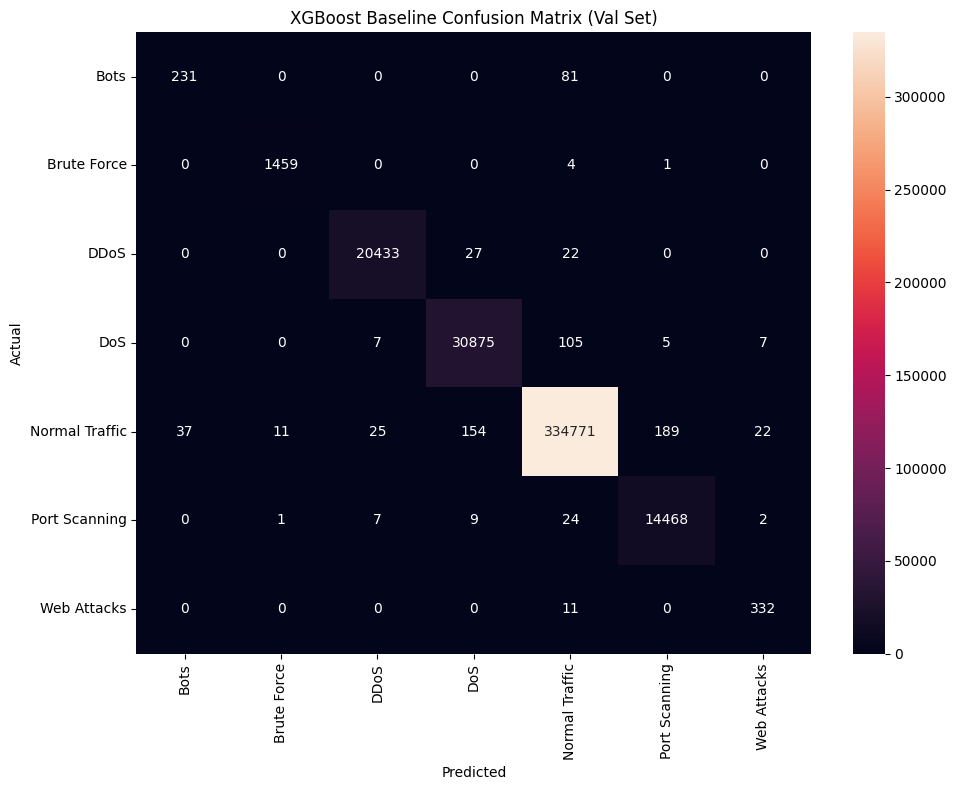

done


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("XGBoost Baseline Confusion Matrix (Val Set)")
plt.tight_layout()
plt.savefig("backend/models/confusion_matrix_baseline.png")
plt.show()
print("done")

Known limitation: Bots class has low recall (0.74) due to limited 
training samples (~1,900 total) and feature overlap with normal traffic. 
This is a data limitation, not a model bug. Tuning may partially improve this.

In [16]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "mlogloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train_scaled, y_train, verbose=False)
    preds = model.predict(X_val_scaled)
    return f1_score(y_val, preds, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

Best F1: 0.9761721748560864
Best params: {'n_estimators': 474, 'max_depth': 5, 'learning_rate': 0.0597789068791208, 'subsample': 0.8888069235256287, 'colsample_bytree': 0.765270614776431, 'min_child_weight': 8}


In [19]:
best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["eval_metric"] = "mlogloss"

xgb_final = XGBClassifier(**best_params)
xgb_final.fit(X_train_scaled, y_train, verbose=False)
print("done")

done


In [20]:
from sklearn.metrics import classification_report

y_pred_final = xgb_final.predict(X_val_scaled)
print(classification_report(y_val, y_pred_final, target_names=le.classes_))

                precision    recall  f1-score   support

          Bots       0.90      0.81      0.86       312
   Brute Force       1.00      1.00      1.00      1464
          DDoS       1.00      1.00      1.00     20482
           DoS       1.00      1.00      1.00     30999
Normal Traffic       1.00      1.00      1.00    335209
 Port Scanning       0.99      1.00      0.99     14511
   Web Attacks       0.98      0.99      0.98       343

      accuracy                           1.00    403320
     macro avg       0.98      0.97      0.98    403320
  weighted avg       1.00      1.00      1.00    403320



In [21]:
import joblib

joblib.dump(xgb_final, "backend/models/xgb_model.pkl")
print("done")

done


In [22]:
import numpy as np

np.save("data/X_train_scaled.npy", X_train_scaled)
np.save("data/X_val_scaled.npy", X_val_scaled)
np.save("data/X_test_scaled.npy", X_test_scaled)
np.save("data/y_train.npy", y_train.values)
np.save("data/y_val.npy", y_val.values)
np.save("data/y_test.npy", y_test.values)
print("done")

done


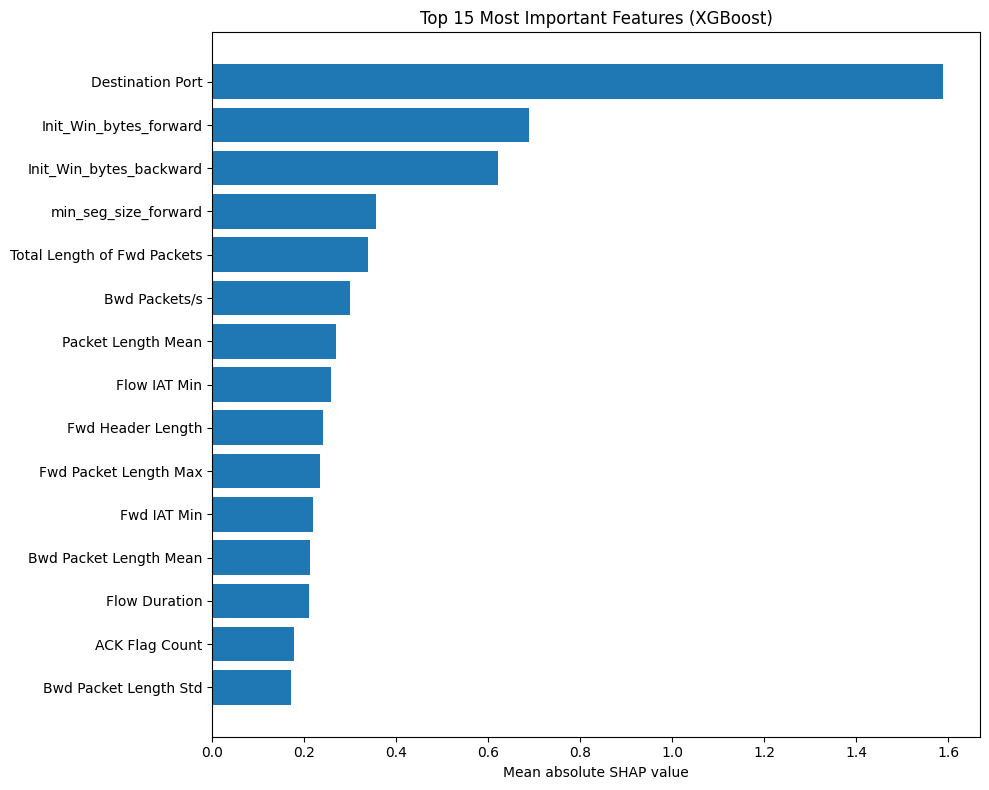

done


In [27]:
# shap_values shape is (500, 52, 7) - samples, features, classes
# take mean absolute value across samples and classes
feature_importance = np.abs(shap_values).mean(axis=(0, 2))  # shape: (52,)

# plot as simple bar chart
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()
sorted_idx = np.argsort(feature_importance)[-15:]  # top 15

plt.figure(figsize=(10, 8))
plt.barh(range(15), feature_importance[sorted_idx])
plt.yticks(range(15), [feature_names[i] for i in sorted_idx])
plt.xlabel("Mean absolute SHAP value")
plt.title("Top 15 Most Important Features (XGBoost)")
plt.tight_layout()
plt.savefig("backend/models/shap_feature_importance.png")
plt.show()
print("done")